In [3]:
# Cài đặt thư viện Kaggle
!pip install -q kaggle

import os
import zipfile

# Khai báo API Token
os.environ['KAGGLE_USERNAME'] = "ngtrungkien" 
os.environ['KAGGLE_KEY'] = "988952db54c4ca4f1157d00dab01e155"

print("Đang kết nối và tải dữ liệu từ Kaggle...")

# Tải bộ dữ liệu Store Sales
!kaggle competitions download -c store-sales-time-series-forecasting

# Giải nén vào thư mục 'kaggle_data'
zip_path = 'store-sales-time-series-forecasting.zip'
extract_path = 'kaggle_data'

if os.path.exists(zip_path):
    print("Đang giải nén dữ liệu...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ HOÀN TẤT! Dữ liệu đã sẵn sàng trong thư mục '{extract_path}'.")
else:
    print("❌ LỖI: Không tải được file. Kiểm tra lại Username và Key.")

Đang kết nối và tải dữ liệu từ Kaggle...



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


store-sales-time-series-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Đang giải nén dữ liệu...
✅ HOÀN TẤT! Dữ liệu đã sẵn sàng trong thư mục 'kaggle_data'.


In [4]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện cho Machine Learning
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cài đặt hiển thị đồ họa
%matplotlib inline
sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Đọc file train.csv từ thư mục đã giải nén
dataset_path = 'kaggle_data/train.csv'

print("Đang tải dữ liệu vào DataFrame...")
df = pd.read_csv(dataset_path, parse_dates=['date'])

# Sắp xếp dữ liệu theo thứ tự thời gian
df = df.sort_values('date')

# Xem thông tin tổng quan
print(f"Tổng số dòng: {df.shape[0]}, Tổng số cột: {df.shape[1]}")
display(df.head())

Đang tải dữ liệu vào DataFrame...
Tổng số dòng: 3000888, Tổng số cột: 6


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1194,1194,2013-01-01,42,CELEBRATION,0.0,0
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0
1192,1192,2013-01-01,42,BOOKS,0.0,0
1191,1191,2013-01-01,42,BEVERAGES,0.0,0


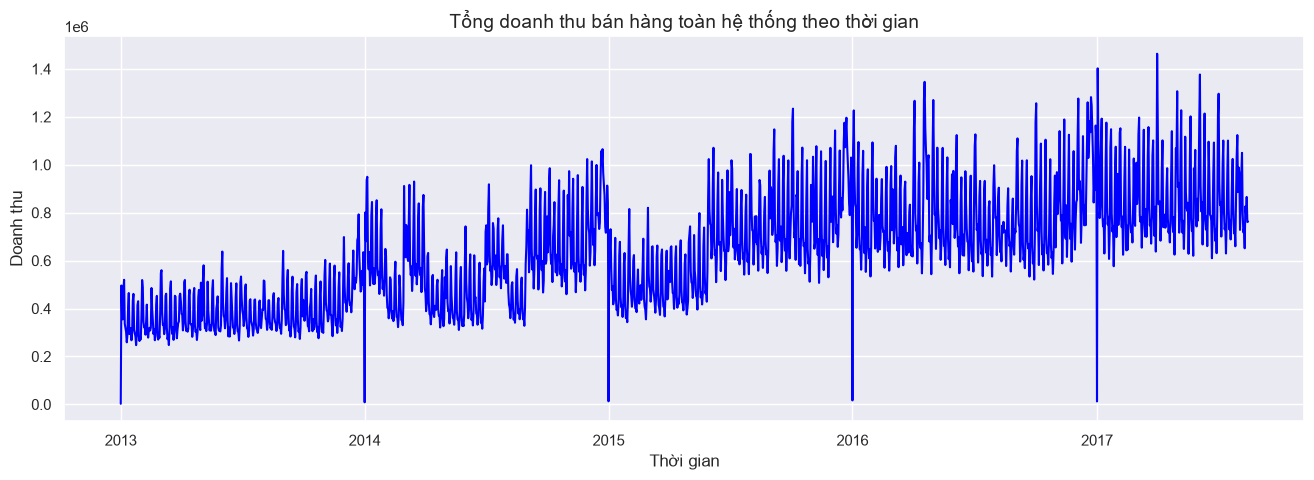

In [7]:
# Tính tổng doanh thu của tất cả cửa hàng theo từng ngày
daily_sales = df.groupby('date')['sales'].sum().reset_index()

# Vẽ biểu đồ doanh thu
plt.figure(figsize=(16, 5))
sns.lineplot(data=daily_sales, x='date', y='sales', color='blue')
plt.title('Tổng doanh thu bán hàng toàn hệ thống theo thời gian', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)
plt.show()

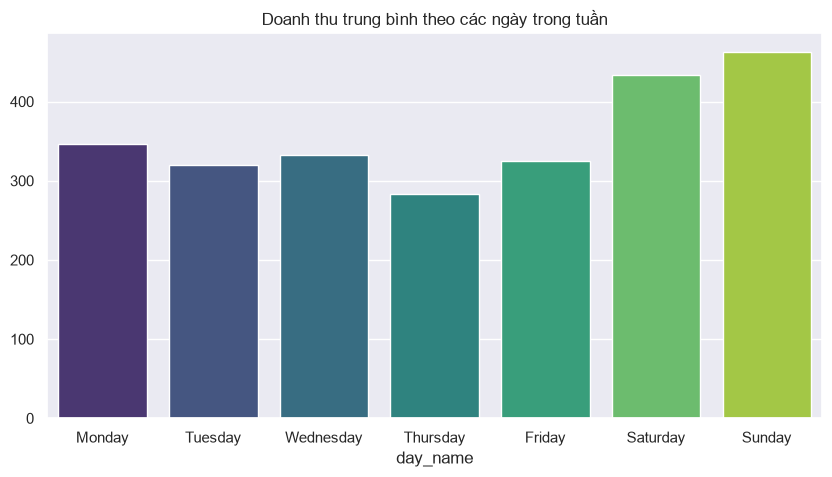

In [8]:
# Tính doanh thu trung bình theo thứ trong tuần
df['day_name'] = df['date'].dt.day_name()
weekly_sales = df.groupby('day_name')['sales'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, palette='viridis')
plt.title('Doanh thu trung bình theo các ngày trong tuần')
plt.show()

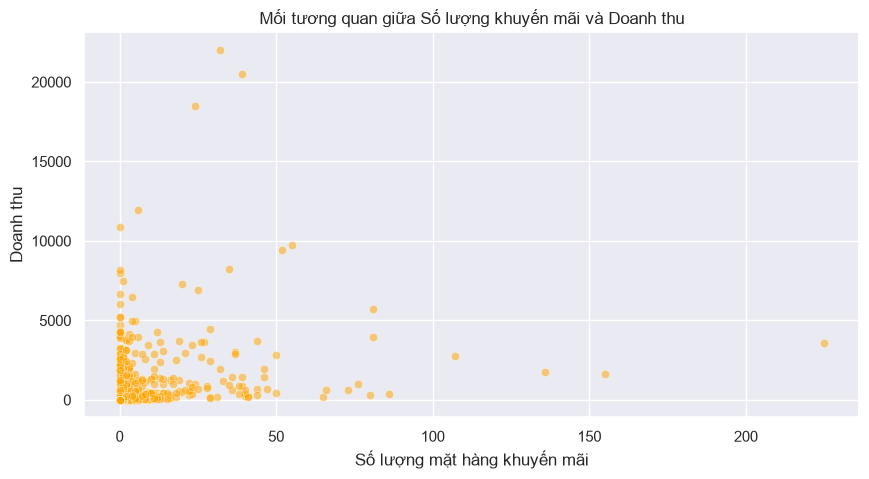

In [13]:
# Vẽ biểu đồ tương quan giữa số lượng khuyến mãi và doanh thu
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(2000), x='onpromotion', y='sales', alpha=0.5, color='orange')
plt.title('Mối tương quan giữa Số lượng khuyến mãi và Doanh thu')
plt.xlabel('Số lượng mặt hàng khuyến mãi')
plt.ylabel('Doanh thu')
plt.show()

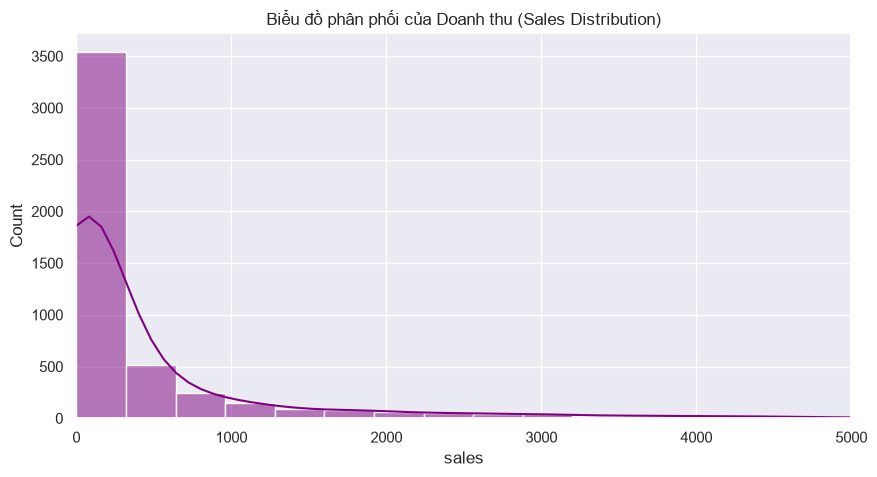

In [14]:
# Vẽ biểu đồ phân phối của biến mục tiêu Sales
plt.figure(figsize=(10, 5))
sns.histplot(df[df['sales'] > 0]['sales'].sample(5000), bins=50, kde=True, color='purple')
plt.title('Biểu đồ phân phối của Doanh thu (Sales Distribution)')
plt.xlim(0, 5000) # Giới hạn trục x để dễ nhìn đồ thị
plt.show()

In [9]:
print("Đang tạo các đặc trưng thời gian (Feature Engineering)...")

# Bóc tách ngày tháng thành các biến số
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek # Thứ 2 = 0, CN = 6

# Biến cờ: Có phải cuối tuần không?
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Lọc bỏ các dòng thiếu doanh thu (nếu có)
df = df.dropna(subset=['sales'])

# Chọn các cột để đưa vào mô hình
features = ['store_nbr', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'is_weekend']
target = 'sales'

display(df[features + [target]].head())

Đang tạo các đặc trưng thời gian (Feature Engineering)...


,store_nbr,onpromotion,year,month,day,day_of_week,is_weekend,sales
0,1,0,2013,1,1,1,0,0.0
1194,42,0,2013,1,1,1,0,0.0
1193,42,0,2013,1,1,1,0,0.0
1192,42,0,2013,1,1,1,0,0.0
1191,42,0,2013,1,1,1,0,0.0


In [10]:
# Chia dữ liệu theo thời gian thực tế: Lấy tháng cuối cùng làm tập Test
split_date = pd.to_datetime('2017-08-01')

train_data = df[df['date'] < split_date]
test_data = df[df['date'] >= split_date]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print(f"Kích thước tập Huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập Kiểm tra (Test): {X_test.shape}")

Kích thước tập Huấn luyện (Train): (2974158, 7)
Kích thước tập Kiểm tra (Test): (26730, 7)


In [11]:
print("Đang huấn luyện mô hình XGBoost. Quá trình này có thể mất vài phút...")

# Khởi tạo mô hình
# Sử dụng tree_method='hist' giúp tăng tốc độ huấn luyện trên tập dữ liệu lớn
model = XGBRegressor(
    n_estimators=150, 
    learning_rate=0.1, 
    max_depth=7,
    tree_method='hist',
    random_state=42
)

# Đưa dữ liệu vào huấn luyện
model.fit(X_train, y_train)

print("✅ Đã huấn luyện xong!")

Đang huấn luyện mô hình XGBoost. Quá trình này có thể mất vài phút...
✅ Đã huấn luyện xong!


--- KẾT QUẢ ĐÁNH GIÁ ---
Mean Absolute Error (MAE): 311.91
Root Mean Squared Error (RMSE): 802.85


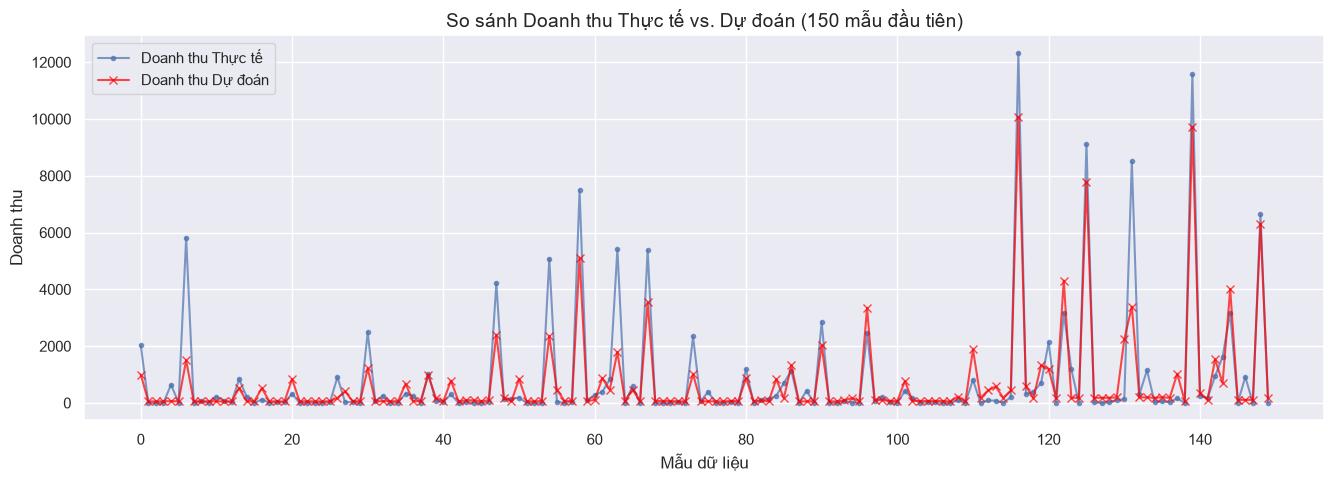

In [12]:
# Thực hiện dự đoán trên tập Test
predictions = model.predict(X_test)

# Doanh thu không thể âm, nên đưa các giá trị dự đoán âm về 0
predictions = np.clip(predictions, a_min=0, a_max=None)

# Tính toán các chỉ số sai số
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Vẽ biểu đồ so sánh trên 150 mẫu đầu tiên của tập Test
plt.figure(figsize=(16, 5))
plt.plot(y_test.values[:150], label='Doanh thu Thực tế', marker='.', alpha=0.7)
plt.plot(predictions[:150], label='Doanh thu Dự đoán', marker='x', alpha=0.7, color='red')
plt.title('So sánh Doanh thu Thực tế vs. Dự đoán (150 mẫu đầu tiên)', fontsize=14)
plt.xlabel('Mẫu dữ liệu', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)
plt.legend()
plt.show()